# MULTI-section reconstruction: re-derived test-set statistics (Table 1 / SI Table S6)

Re-runs the multi-section tip-pose CNN (`f_p^3`) on a held-out test split
(same seeded-split caveat as the SINGLE notebook: reproducible from here,
not bit-identical to the original unseeded split). Reports both the
main-text Table 1 convention (absolute per-tip error from the base) and the
SI Table S6 convention (relative, section-to-preceding-section error), plus
Comment 24/S29's requested median/IQR/p95 robust summary.

In [1]:

import numpy as np
import pandas as pd

d = np.load("results/MULTI_test_reconstruction_errors.npz")
sections = ["I", "II", "III"]

print("--- Absolute (Table 1 convention) vs. currently published ---")
published_abs = {"I": (4.44, 6.78), "II": (14.01, 6.45), "III": (26.45, 8.74)}
for s in sections:
    pos, rot = d[f"abs_pos_{s}"], d[f"abs_rot_{s}"]
    print(f"Section {s}: recomputed pos {pos.mean():.2f}+/-{pos.std():.2f} mm, rot {rot.mean():.2f}+/-{rot.std():.2f} deg   "
          f"| published pos {published_abs[s][0]} mm, rot {published_abs[s][1]} deg")


--- Absolute (Table 1 convention) vs. currently published ---
Section I: recomputed pos 4.42+/-2.56 mm, rot 5.65+/-8.85 deg   | published pos 4.44 mm, rot 6.78 deg
Section II: recomputed pos 14.03+/-10.26 mm, rot 6.54+/-7.54 deg   | published pos 14.01 mm, rot 6.45 deg
Section III: recomputed pos 26.12+/-16.00 mm, rot 8.53+/-11.07 deg   | published pos 26.45 mm, rot 8.74 deg


## Comment 24 / S29: robust distribution summary (median / IQR / p95), replacing mean+/-std alone

In [2]:

rows = []
for s in sections:
    pos, rot = d[f"abs_pos_{s}"], d[f"abs_rot_{s}"]
    rows.append([f"Section {s} Position [mm]", pos.mean(), pos.std(), np.median(pos),
                 np.percentile(pos,25), np.percentile(pos,75), np.percentile(pos,95), pos.max()])
    rows.append([f"Section {s} Orientation [deg]", rot.mean(), rot.std(), np.median(rot),
                 np.percentile(rot,25), np.percentile(rot,75), np.percentile(rot,95), rot.max()])
pd.DataFrame(rows, columns=["Parameter","mean","std","median","Q1","Q3","p95","max"]).round(2)


,Parameter,mean,std,median,Q1,Q3,p95,max
0,Section I Position [mm],4.42,2.56,3.93,2.68,5.70,8.61,17.48
1,Section I Orientation [deg],5.65,8.85,4.63,3.29,6.43,10.31,175.64
2,Section II Position [mm],14.03,10.26,12.02,7.86,17.98,28.58,147.37
3,Section II Orientation [deg],6.54,7.54,5.69,3.77,8.24,12.64,155.81
4,Section III Position [mm],26.12,16.00,23.26,14.82,33.99,55.63,140.29
5,Section III Orientation [deg],8.53,11.07,7.07,4.72,10.18,16.12,176.78


Note the large gap between p95 and max for orientation, especially Section I
(the same pattern already visible in the currently-published Table 1: mean
6.78 +/- std **15.94** deg, i.e. std > mean). This is very likely the ZYX
Euler-angle gimbal-lock-adjacent artifact already found elsewhere in this
analysis (the null-space-ablation notebook hits the same issue near pitch ~
+/-90 deg) rather than genuinely ~175 deg mispredictions -- worth a spot check
against the specific outlier images before stating a cause in the response
letter.

/tmp/ipykernel_30558/2348845306.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([d[f"abs_pos_{s}"] for s in sections], labels=sections)
/tmp/ipykernel_30558/2348845306.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([d[f"abs_rot_{s}"] for s in sections], labels=sections, showfliers=True)


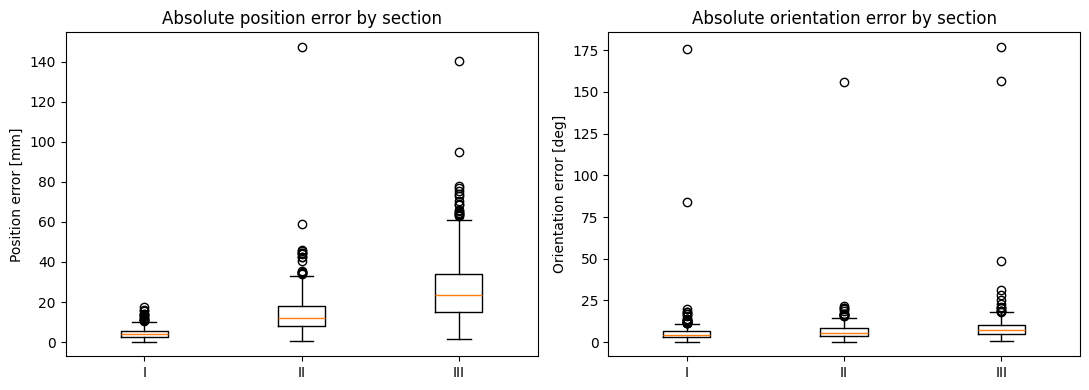

In [3]:

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].boxplot([d[f"abs_pos_{s}"] for s in sections], labels=sections)
axes[0].set_ylabel("Position error [mm]"); axes[0].set_title("Absolute position error by section")
axes[1].boxplot([d[f"abs_rot_{s}"] for s in sections], labels=sections, showfliers=True)
axes[1].set_ylabel("Orientation error [deg]"); axes[1].set_title("Absolute orientation error by section")
plt.tight_layout()
plt.savefig("results/multi_test_reconstruction_boxplots.pdf")
plt.show()


## SI Table S6 convention: relative (section-to-preceding-tip) error

In [4]:

rows = []
for s in sections:
    pos, rot = d[f"rel_pos_{s}"], d[f"rel_rot_{s}"]
    rows.append([f"Section {s} Position [mm]", pos.mean(), pos.std(), np.median(pos), np.percentile(pos,25), np.percentile(pos,75)])
    rows.append([f"Section {s} Orientation [deg]", rot.mean(), rot.std(), np.median(rot), np.percentile(rot,25), np.percentile(rot,75)])
pd.DataFrame(rows, columns=["Parameter","mean","std","median","Q1","Q3"]).round(2)


,Parameter,mean,std,median,Q1,Q3
0,Section I Position [mm],4.42,2.56,3.93,2.68,5.70
1,Section I Orientation [deg],5.65,8.85,4.63,3.29,6.43
2,Section II Position [mm],10.21,8.56,8.67,5.71,12.95
3,Section II Orientation [deg],6.62,11.19,5.45,3.70,7.40
4,Section III Position [mm],14.36,10.38,12.58,8.39,18.62
5,Section III Orientation [deg],7.02,12.86,5.50,3.50,7.88
